# Trening modelu oceny stylu jazdy (ExtraTrees)
Poniższy kod realizuje proces wczytywania sekwencji z sieci CAN, ekstrakcji cech w oknach czasowych, nadawania etykiet przy użyciu stworzonych reguł (pseudoetykiety) oraz trenowania modelu `ExtraTreesClassifier` do klasyfikacji stylów jazdy. Model na końcu eksportowany jest z użyciem `emlearn` do wbudowania w platformę ESP32.

In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, balanced_accuracy_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import MinMaxScaler

import emlearn

DATA_GLOB = "data/*.csv"
OUT_DIR = "prepared_data"
os.makedirs(OUT_DIR, exist_ok=True)

CLASS_ORDER = ["normal", "eco", "aggressive"]

WIN_SEC = 5.0
STEP_SEC = 2.5
TARGET_HZ = 10.0
WIN_N = int(WIN_SEC * TARGET_HZ)    # 50 samples = exactly 5s at 10Hz
STEP_N = int(STEP_SEC * TARGET_HZ)  # 25 samples = exactly 2.5s at 10Hz


## 1. Wczytanie i czyszczenie danych
Ujednolicamy timestampy, odrzucamy momenty kiedy silnik był zgaszony (`ignition == 0`) lub auto cofało (`rear_gear == 1`). Wyliczamy również przyspieszenie (a) oraz szarpnięcie (jerk). Data próbkowania jest domyślnie ustalona do maksymalnie 10Hz na podstawie limitów danych dostarczanych z sieci.

In [2]:
def load_one_csv(path):
    df = pd.read_csv(path)

    needed = ["timestamp", "ignition", "speed", "rpm", "throttle", "brake", "rear_gear"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in {path}: {missing}")

    for c in needed:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.dropna(subset=needed).copy()
    df = df.sort_values("timestamp")
    df = df.drop_duplicates(subset=["timestamp"], keep="first")

    # Resample to fixed 10Hz grid (100ms) before filtering.
    # CAN is event-driven: signal holds its last value until next frame -> ffill.
    t_start = int(df["timestamp"].iloc[0] // 100) * 100
    t_end   = int(df["timestamp"].iloc[-1] // 100) * 100
    grid = np.arange(t_start, t_end + 100, 100, dtype=np.int64)

    df = df.set_index("timestamp")
    df = df.reindex(df.index.union(grid)).sort_index()
    for col in ["speed", "rpm", "throttle", "brake", "ignition", "rear_gear"]:
        df[col] = df[col].ffill().fillna(0)
    df = df.reindex(grid).reset_index().rename(columns={"index": "timestamp"})

    # Drive filters: ignition on, not reversing, valid speed
    df = df[(df["ignition"] == 1) & (df["rear_gear"] == 0) & (df["speed"] >= 0)].copy()
    if df.empty:
        return df

    # dt is now always 0.1s; reset derivatives at segment gaps (ignition-off breaks)
    df = df.reset_index(drop=True)
    DT = 0.1
    boundary = (df["timestamp"].diff() > 150).fillna(True)

    df["dt"] = DT
    df["a_ms2"] = (df["speed"].diff() / 3.6) / DT
    df["a_ms2"] = df["a_ms2"].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    df.loc[boundary, "a_ms2"] = 0.0

    df["jerk_ms3"] = df["a_ms2"].diff() / DT
    df["jerk_ms3"] = df["jerk_ms3"].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    df.loc[boundary, "jerk_ms3"] = 0.0

    df["d_throttle_s"] = df["throttle"].diff() / DT
    df["d_throttle_s"] = df["d_throttle_s"].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    df.loc[boundary, "d_throttle_s"] = 0.0

    df["d_brake_s"] = df["brake"].diff() / DT
    df["d_brake_s"] = df["d_brake_s"].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    df.loc[boundary, "d_brake_s"] = 0.0

    df["source_file"] = os.path.basename(path)
    return df.reset_index(drop=True)

files = sorted(glob.glob(DATA_GLOB))
trips = [load_one_csv(p) for p in files]
raw_all = pd.concat(trips, ignore_index=True)

print("Liczba plikow:", len(files))
print("Liczba wierszy po czyszczeniu:", len(raw_all))
raw_all.head()


Liczba plikow: 29
Liczba wierszy po czyszczeniu: 567382


,timestamp,ignition,speed,rpm,throttle,brake,fuel_level,fuel_cons,distance,range,oil_temp,esp,rear_gear,dt,a_ms2,jerk_ms3,d_throttle_s,d_brake_s,source_file
0,97400,1.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.1,0.0,0.0,0.0,0.0,20260404_091932.csv
1,97500,1.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.1,0.0,0.0,0.0,10.0,20260404_091932.csv
2,128400,1.0,0.0,1369.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.1,0.0,0.0,0.0,0.0,20260404_091932.csv
3,128500,1.0,0.0,1369.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.1,0.0,0.0,0.0,0.0,20260404_091932.csv
4,128600,1.0,0.0,1368.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.1,0.0,0.0,0.0,0.0,20260404_091932.csv


## 2. Okna czasowe
Pojedyncza inferencja modelu odbywa się dla całych fragmentów trasy. Stosujemy technikę przesuwnych okien czasowych (w wielkości `WIN_SEC` sekund) przesuniętych w czasie o `STEP_SEC` do minimalizacji opóźnień między wyznaczeniem kolejnego parametru. Wynikowe wartości odzwierciedlają średnie zachowanie z przejazdów.

In [3]:
def make_window_features(df, win_n=WIN_N, step_n=STEP_N):
    rows = []
    if len(df) < win_n:
        return pd.DataFrame()

    for start in range(0, len(df) - win_n + 1, step_n):
        w = df.iloc[start:start + win_n]

        # Skip stop windows — handled as "normal" directly in MCU firmware
        if w["speed"].mean() < 2.0:
            continue

        feat = {
            "source_file": w["source_file"].iloc[-1],
            "ts_end": int(w["timestamp"].iloc[-1]),

            "speed_mean": w["speed"].mean(),
            "speed_std": w["speed"].std(ddof=0),
            "speed_p95": np.percentile(w["speed"], 95),

            "rpm_mean": w["rpm"].mean(),
            "rpm_std": w["rpm"].std(ddof=0),
            "rpm_p95": np.percentile(w["rpm"], 95),

            "throttle_mean": w["throttle"].mean(),
            "throttle_std": w["throttle"].std(ddof=0),
            "throttle_p95": np.percentile(w["throttle"], 95),
            "throttle_dp95": np.percentile(w["d_throttle_s"], 95),

            "brake_mean": w["brake"].mean(),
            "brake_p95": np.percentile(w["brake"], 95),
            "brake_dp95": np.percentile(w["d_brake_s"], 95),

            "a_mean": w["a_ms2"].mean(),
            "a_std": w["a_ms2"].std(ddof=0),
            "a_p95": np.percentile(w["a_ms2"], 95),
            "a_p05": np.percentile(w["a_ms2"], 5),
            "abs_a_mean": np.abs(w["a_ms2"]).mean(),

            "jerk_abs_mean": np.abs(w["jerk_ms3"]).mean(),
            "jerk_abs_p95": np.percentile(np.abs(w["jerk_ms3"]), 95),
        }
        rows.append(feat)

    return pd.DataFrame(rows)

windows = []
for t in trips:
    wf = make_window_features(t)
    if len(wf):
        windows.append(wf)

feat_df = pd.concat(windows, ignore_index=True)
print("Liczba okien:", len(feat_df))
feat_df.head()

Liczba okien: 20954


,source_file,ts_end,speed_mean,speed_std,speed_p95,rpm_mean,rpm_std,rpm_p95,throttle_mean,throttle_std,...,brake_mean,brake_p95,brake_dp95,a_mean,a_std,a_p95,a_p05,abs_a_mean,jerk_abs_mean,jerk_abs_p95
0,20260404_091932.csv,137800,2.00,3.200000,8.00,1215.90,264.593216,1368.55,1.66,6.192286,...,0.10,0.0,0.0,0.444444,1.401058,2.777778,0.000000,0.444444,5.555556,27.777778
1,20260404_091932.csv,140300,6.94,3.971952,12.00,1304.04,159.428349,1594.00,22.74,25.543539,...,0.00,0.0,0.0,0.666667,1.625415,2.777778,0.000000,0.777778,12.222222,43.055556
2,20260404_091932.csv,142800,11.82,2.355334,15.55,1281.12,191.020380,1594.00,40.60,20.632014,...,0.00,0.0,0.0,0.444444,1.160034,2.777778,0.000000,0.555556,11.111111,27.777778
3,20260404_091932.csv,145300,15.06,1.678213,17.00,1200.60,105.997358,1310.10,25.00,23.583045,...,0.00,0.0,0.0,0.166667,1.166667,2.777778,-1.527778,0.500000,10.000000,27.777778
4,20260404_091932.csv,147800,15.08,1.481081,17.00,1168.34,97.832430,1307.65,5.48,14.337699,...,1.36,13.1,42.0,-0.166667,1.025899,0.000000,-2.777778,0.388889,7.777778,27.777778


## 3. Pseudo-etykiety (Reguły decyzyjne)
Na bazie zebranych cech konstruujemy etykiety decyzyjne (`normal`, `eco`, `aggressive`). Następnie rozdzielamy otrzymany zbiór na warstwę testową i treningową oraz skalujemy do 16 bitów. Użycie `GroupShuffleSplit` pomaga unikać przenikania "czasowego" danych podczas trenowania.

In [ ]:
def pseudo_label(row):
    # --- AGGRESSIVE: OR logic — any single extreme event is enough ---
    # Note: at fixed dt=0.1s, speed is integer km/h -> a quantised to 2.778 m/s² steps.
    # Use abs_a_mean (averaged -> continuous) instead of a_p95 (quantisation artifact).
    if row["a_p05"] < -5.0:           # hard braking: 2+ km/h decel per 100ms (~5% of windows)
        return "aggressive"
    if row["abs_a_mean"] > 0.70:      # sustained aggressive dynamics (~10% of windows, p90)
        return "aggressive"
    if row["throttle_dp95"] > 120.0:  # sudden throttle stab
        return "aggressive"
    if row["brake_p95"] > 100.0:      # strong brake pressure
        return "aggressive"

    # --- ECO: AND logic — all conditions must hold simultaneously ---
    eco = (
        row["abs_a_mean"]    < 0.40   # smooth longitudinal dynamics
        and row["rpm_mean"]      < 3000  # low engine load
        and row["throttle_dp95"] < 40.0  # no sudden throttle changes
        and row["throttle_mean"] < 55.0  # gentle average throttle
        and 20.0 <= row["speed_mean"] <= 120.0  # cruising range
    )
    if eco:
        return "eco"

    return "normal"

feat_df["label"] = feat_df.apply(pseudo_label, axis=1)
print(feat_df["label"].value_counts())

feature_cols = [c for c in feat_df.columns if c not in ["source_file", "ts_end", "label"]]
X = feat_df[feature_cols].copy()
y = feat_df["label"].copy()
groups = feat_df["source_file"].copy()

split = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(split.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

quantizer = MinMaxScaler(feature_range=(-30000, 30000), clip=True)
X_train_q = np.rint(quantizer.fit_transform(X_train)).astype(np.int16)
X_test_q  = np.rint(quantizer.transform(X_test)).astype(np.int16)


label
normal        15493
aggressive     4011
eco            1450
Name: count, dtype: int64


## 4. Trenowanie Modelu
Stosujemy model `ExtraTreesClassifier` z ograniczeniami pod architekturę wbudowaną: `n_estimators=60` i `max_depth=7` (zmniejszone z 80/8) — redukuje rozmiar eksportowanego pliku `.h` o ~25% przy minimalnej stracie dokładności.

In [13]:
model = ExtraTreesClassifier(
    n_estimators=60,   # reduced from 80 — smaller .h export (~25% less flash)
    max_depth=7,       # reduced from 8 — marginal accuracy loss, less overfitting
    min_samples_leaf=12,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_q, y_train)
y_pred = model.predict(X_test_q)

print("Balanced accuracy:", round(balanced_accuracy_score(y_test, y_pred), 4))
print("Macro F1:", round(f1_score(y_test, y_pred, average="macro"), 4))
print(classification_report(y_test, y_pred, digits=4))
print("Confusion matrix [normal, eco, aggressive]:")
print(confusion_matrix(y_test, y_pred, labels=CLASS_ORDER))

Balanced accuracy: 0.8663
Macro F1: 0.7128
              precision    recall  f1-score   support

  aggressive     0.7531    0.8568    0.8016      1257
         eco     0.3302    1.0000    0.4965       527
      normal     0.9684    0.7422    0.8403      5318

    accuracy                         0.7816      7102
   macro avg     0.6839    0.8663    0.7128      7102
weighted avg     0.8829    0.7816    0.8080      7102

Confusion matrix [normal, eco, aggressive]:
[[3947 1018  353]
 [   0  527    0]
 [ 129   51 1077]]


## 5. Cross-walidacja (GroupKFold)
Weryfikujemy stabilność modelu na 5 foldach, gdzie każdy fold zawiera inne trasy (pliki). Niskie odchylenie standardowe potwierdza, że wyniki nie są artefaktem jednego podziału.

In [14]:
from sklearn.model_selection import GroupKFold

print("=== GroupKFold Cross-Validation (5 folds) ===\n")
gkf = GroupKFold(n_splits=5)

cv_bal_acc, cv_f1 = [], []

for fold_i, (tr_idx, va_idx) in enumerate(gkf.split(X, y, groups=groups)):
    scaler_cv = MinMaxScaler(feature_range=(-30000, 30000), clip=True)
    X_tr_q = np.rint(scaler_cv.fit_transform(X.iloc[tr_idx])).astype(np.int16)
    X_va_q = np.rint(scaler_cv.transform(X.iloc[va_idx])).astype(np.int16)

    cv_model = ExtraTreesClassifier(
        n_estimators=60, max_depth=7, min_samples_leaf=12,
        max_features="sqrt", class_weight="balanced_subsample",
        random_state=42, n_jobs=-1
    )
    cv_model.fit(X_tr_q, y.iloc[tr_idx])
    y_va_pred = cv_model.predict(X_va_q)

    ba = balanced_accuracy_score(y.iloc[va_idx], y_va_pred)
    f1 = f1_score(y.iloc[va_idx], y_va_pred, average="macro")
    cv_bal_acc.append(ba)
    cv_f1.append(f1)
    print(f"Fold {fold_i + 1}: balanced_acc={ba:.4f}  macro_F1={f1:.4f}")

print(f"\nMean balanced_acc : {np.mean(cv_bal_acc):.4f} ± {np.std(cv_bal_acc):.4f}")
print(f"Mean macro_F1     : {np.mean(cv_f1):.4f} ± {np.std(cv_f1):.4f}")

=== GroupKFold Cross-Validation (5 folds) ===

Fold 1: balanced_acc=0.8886  macro_F1=0.7252
Fold 2: balanced_acc=0.9011  macro_F1=0.7330
Fold 3: balanced_acc=0.8361  macro_F1=0.6588
Fold 4: balanced_acc=0.8906  macro_F1=0.7124
Fold 5: balanced_acc=0.8137  macro_F1=0.6553

Mean balanced_acc : 0.8660 ± 0.0346
Mean macro_F1     : 0.6969 ± 0.0332


## 6. Macierz pomyłek — wizualizacja
Lewa: liczba predykcji. Prawa: macierz znormalizowana wierszowo (recall per class) — pokazuje jak dobrze model odzyskuje każdą klasę.

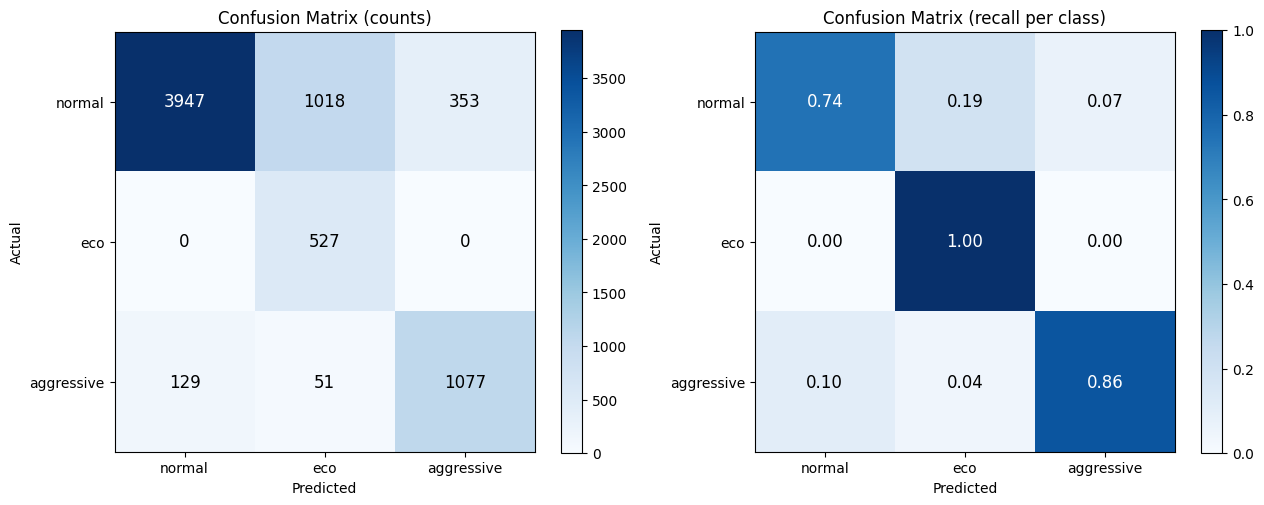

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cm = confusion_matrix(y_test, y_pred, labels=CLASS_ORDER)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    [".0f", ".2f"],
    ["Confusion Matrix (counts)", "Confusion Matrix (recall per class)"]
):
    im = ax.imshow(data, cmap="Blues")
    ax.set_xticks(range(len(CLASS_ORDER)))
    ax.set_yticks(range(len(CLASS_ORDER)))
    ax.set_xticklabels(CLASS_ORDER)
    ax.set_yticklabels(CLASS_ORDER)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)
    for i in range(len(CLASS_ORDER)):
        for j in range(len(CLASS_ORDER)):
            ax.text(j, i, format(data[i, j], fmt),
                    ha="center", va="center", fontsize=12,
                    color="white" if data[i, j] > data.max() * 0.5 else "black")
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

## 7. Analiza rozkładów cech — błędne predykcje
Badamy rozkłady cech dla okien błędnie sklasyfikowanych przez model, w szczególności:
- `normal` → `eco` (3068 przypadków)
- `normal` → `aggressive` (2530 przypadków)

Pozwala to oceniç, czy granica decyzyjna pseudo-etykiet jest zbyt permisywna lub czy cechy nie separują klas wystarczająco.

=== Sample counts ===
  normal->normal (ok): 3947
  normal->eco (FP): 1018
  normal->aggressive (FP): 353

=== Median feature values per group ===
                         abs_a_mean  jerk_abs_mean  jerk_abs_p95  throttle_mean  throttle_dp95  brake_mean  brake_p95     a_p95  a_p05    a_mean  rpm_mean  speed_mean
normal->normal (ok)        0.277778       5.000000     27.777778          87.78           20.0         0.0        0.0  0.000000    0.0  0.055556   3233.54      117.96
normal->eco (FP)           0.222222       4.444444     27.777778          35.45           45.5         0.0        0.0  0.000000    0.0 -0.055556   2009.49       65.07
normal->aggressive (FP)    0.611111      11.111111     27.777778          52.50           55.5         0.0        0.0  2.777778    0.0  0.222222   2096.94       57.96


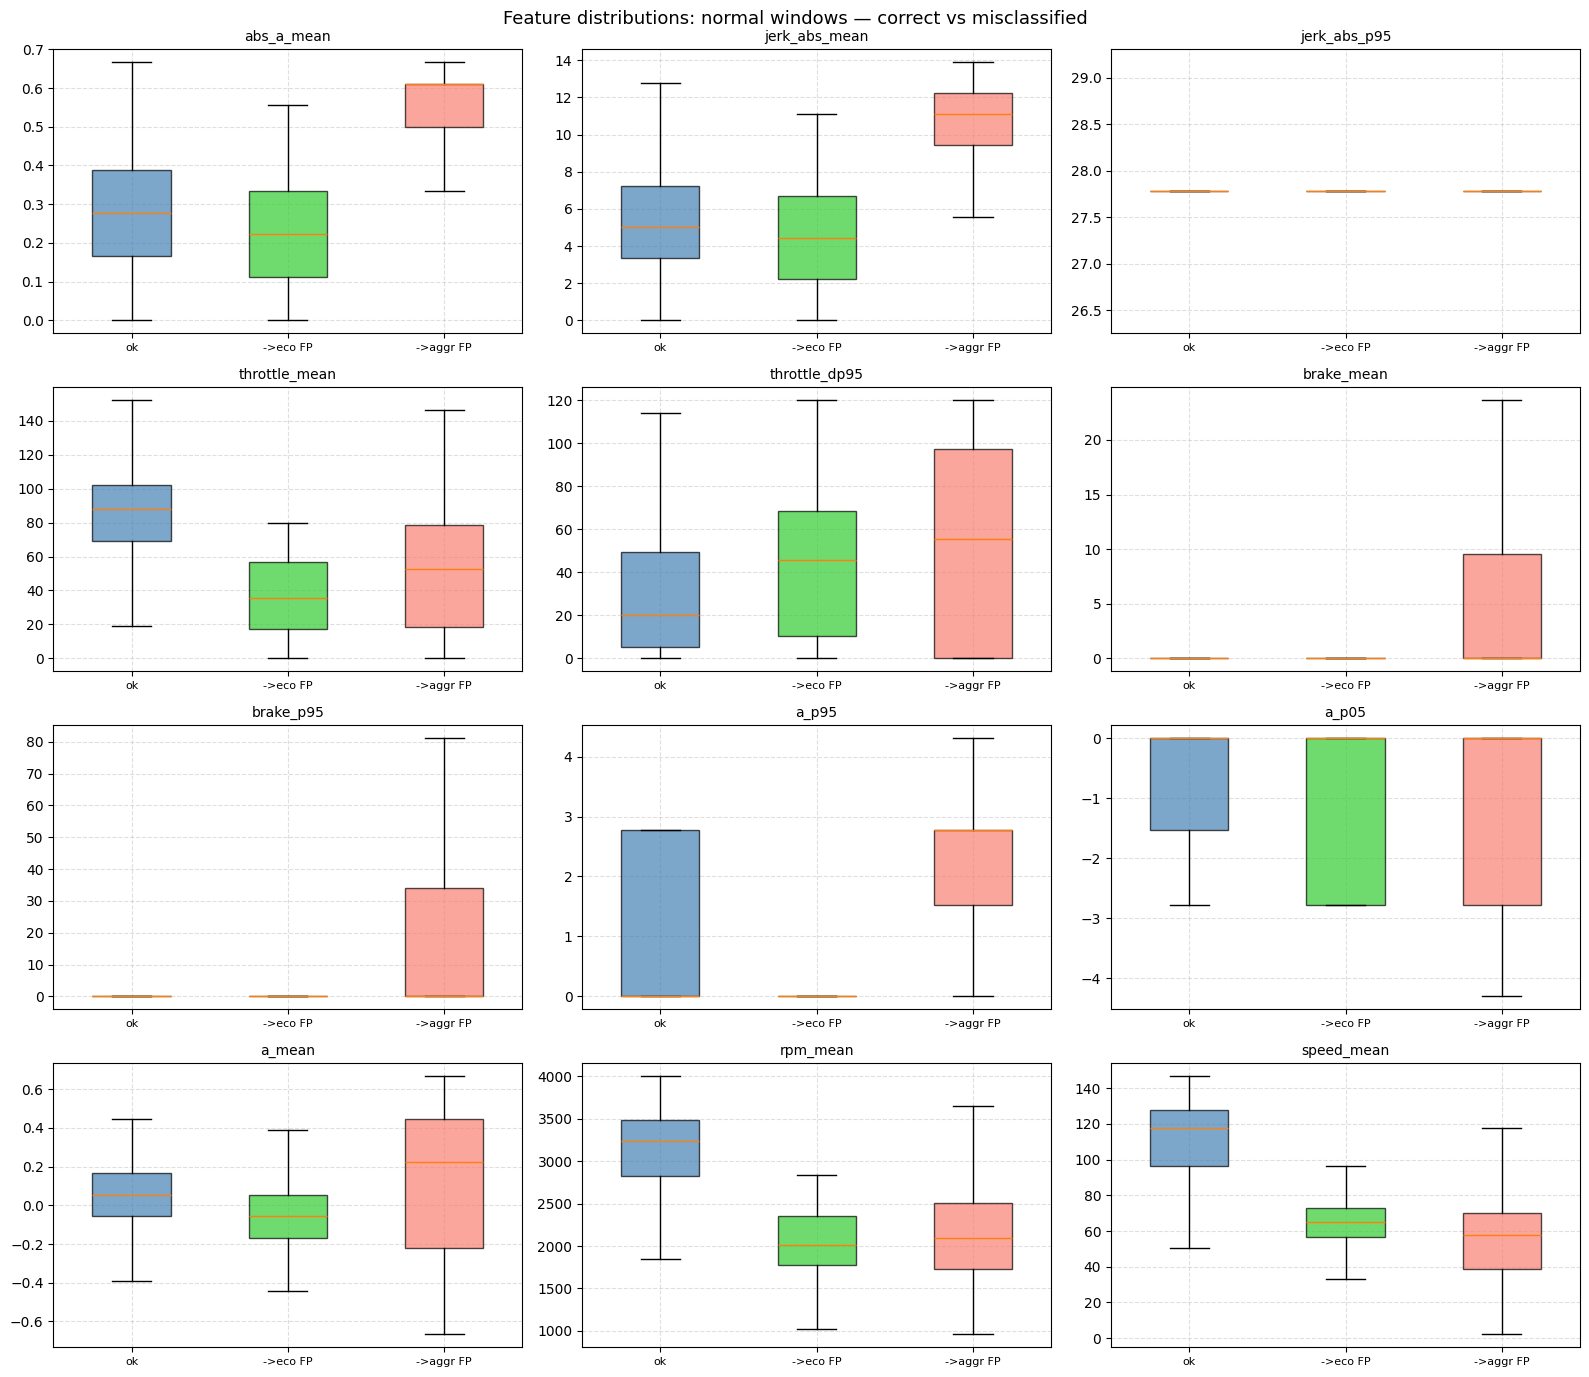


=== normal->eco FP — feature percentiles (25/50/75) ===
     abs_a_mean  jerk_abs_mean  jerk_abs_p95  throttle_mean  throttle_dp95  brake_mean  brake_p95  a_p95     a_p05    a_mean  rpm_mean  speed_mean
25%    0.111111       2.222222     27.777778          17.50          10.25         0.0        0.0    0.0 -2.777778 -0.166667  1781.615      56.445
50%    0.222222       4.444444     27.777778          35.45          45.50         0.0        0.0    0.0  0.000000 -0.055556  2009.490      65.070
75%    0.333333       6.666667     27.777778          56.50          68.50         0.0        0.0    0.0  0.000000  0.055556  2355.880      72.870

=== normal->aggressive FP — feature percentiles (25/50/75) ===
     abs_a_mean  jerk_abs_mean  jerk_abs_p95  throttle_mean  throttle_dp95  brake_mean  brake_p95     a_p95     a_p05    a_mean  rpm_mean  speed_mean
25%    0.500000       9.444444     27.777778          18.70            0.0        0.00        0.0  1.527778 -2.777778 -0.222222   1728.36    

In [16]:
import matplotlib.pyplot as plt

# Build test dataframe with true/predicted labels and raw (unquantized) feature values
test_df = X_test.copy()
test_df["y_true"] = y_test.values
test_df["y_pred"] = y_pred

# Misclassification groups for the dominant class (normal)
mask_norm_true = test_df["y_true"] == "normal"
mask_norm_ok   = mask_norm_true & (test_df["y_pred"] == "normal")
mask_norm_eco  = mask_norm_true & (test_df["y_pred"] == "eco")
mask_norm_aggr = mask_norm_true & (test_df["y_pred"] == "aggressive")

groups_masks = {
    "normal->normal (ok)":     mask_norm_ok,
    "normal->eco (FP)":        mask_norm_eco,
    "normal->aggressive (FP)": mask_norm_aggr,
}

# Features most relevant to pseudo-label decision rules
KEY_FEATURES = [
    "abs_a_mean", "jerk_abs_mean", "jerk_abs_p95",
    "throttle_mean", "throttle_dp95",
    "brake_mean", "brake_p95",
    "a_p95", "a_p05", "a_mean",
    "rpm_mean", "speed_mean",
]

print("=== Sample counts ===")
for name, mask in groups_masks.items():
    print(f"  {name}: {mask.sum()}")

print("\n=== Median feature values per group ===")
stats = {name: test_df.loc[mask, KEY_FEATURES].median() for name, mask in groups_masks.items()}
print(pd.DataFrame(stats).T.to_string())

# Box plots — 4x3 grid
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()
colors = ["steelblue", "limegreen", "salmon"]
group_labels = ["ok", "->eco FP", "->aggr FP"]

for ax, feat in zip(axes, KEY_FEATURES):
    data = [test_df.loc[mask, feat].values for mask in groups_masks.values()]
    bp = ax.boxplot(data, patch_artist=True, showfliers=False, widths=0.5)
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(feat, fontsize=10)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(group_labels, fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.4)

for ax in axes[len(KEY_FEATURES):]:
    ax.set_visible(False)

plt.suptitle("Feature distributions: normal windows — correct vs misclassified", fontsize=13)
plt.tight_layout()
plt.show()

# Percentile breakdown for false positives
for name, mask in [("normal->eco FP", mask_norm_eco), ("normal->aggressive FP", mask_norm_aggr)]:
    print(f"\n=== {name} — feature percentiles (25/50/75) ===")
    print(test_df.loc[mask, KEY_FEATURES].describe().loc[["25%", "50%", "75%"]].to_string())

# Overlap check: how many FP windows would PASS pseudo-label thresholds?
print("\n=== Pseudo-label threshold overlap for normal->eco FP windows ===")
fp = test_df.loc[mask_norm_eco]
print(f"  abs_a_mean < 0.45:      {(fp['abs_a_mean'] < 0.45).mean():.1%}")
print(f"  jerk_abs_mean < 0.9:    {(fp['jerk_abs_mean'] < 0.9).mean():.1%}")
print(f"  throttle_mean < 22:     {(fp['throttle_mean'] < 22.0).mean():.1%}")
print(f"  brake_mean < 20:        {(fp['brake_mean'] < 20.0).mean():.1%}")
print(f"  rpm_mean < 2800:        {(fp['rpm_mean'] < 2800.0).mean():.1%}")
print(f"  speed_mean in [20,95]:  {((fp['speed_mean']>=20)&(fp['speed_mean']<=95)).mean():.1%}")

print("\n=== Pseudo-label threshold overlap for normal->aggressive FP windows ===")
fa = test_df.loc[mask_norm_aggr]
print(f"  a_p95 > 1.8:            {(fa['a_p95'] > 1.8).mean():.1%}")
print(f"  a_p05 < -2.2:           {(fa['a_p05'] < -2.2).mean():.1%}")
print(f"  jerk_abs_p95 > 28.0:     {(fa['jerk_abs_p95'] > 28.0).mean():.1%}")
print(f"  throttle_dp95 > 120:    {(fa['throttle_dp95'] > 120.0).mean():.1%}")
print(f"  brake_p95 > 180:        {(fa['brake_p95'] > 180.0).mean():.1%}")


## 7a. Rozkłady percentyli cech — dobór progów
Pomaga wybrać progi dla nowej metody etykietowania OR/AND.
- Linia **p95** (czerwona) — potencjalny próg dla cechy agresywnej (OR)
- Linia **p10** (niebieska) — potencjalny próg dla cechy eco (AND)

=== Aggressive feature percentiles (all windows) ===
        a_p95     a_p05  jerk_abs_p95  throttle_dp95  brake_p95
p1   0.000000 -5.555556      0.000000           0.00        0.0
p5   0.000000 -2.777778      0.000000           0.00        0.0
p10  0.000000 -2.777778      0.000000           0.00        0.0
p25  0.000000 -2.777778     27.777778           0.00        0.0
p50  0.000000  0.000000     27.777778          20.00        0.0
p75  2.777778  0.000000     27.777778          65.50        0.0
p90  2.777778  0.000000     43.055556         115.50       46.0
p95  2.777778  0.000000     55.555556         150.50       91.1
p99  5.555556  0.000000     70.833333         232.47      174.0

=== Eco feature percentiles (all windows) ===
     abs_a_mean   rpm_mean  throttle_dp95  throttle_mean  speed_mean
p1     0.000000  1022.2604           0.00         0.0000      3.8000
p5     0.000000  1210.7530           0.00         0.0000     11.4330
p10    0.055556  1450.0740           0.00         1.5

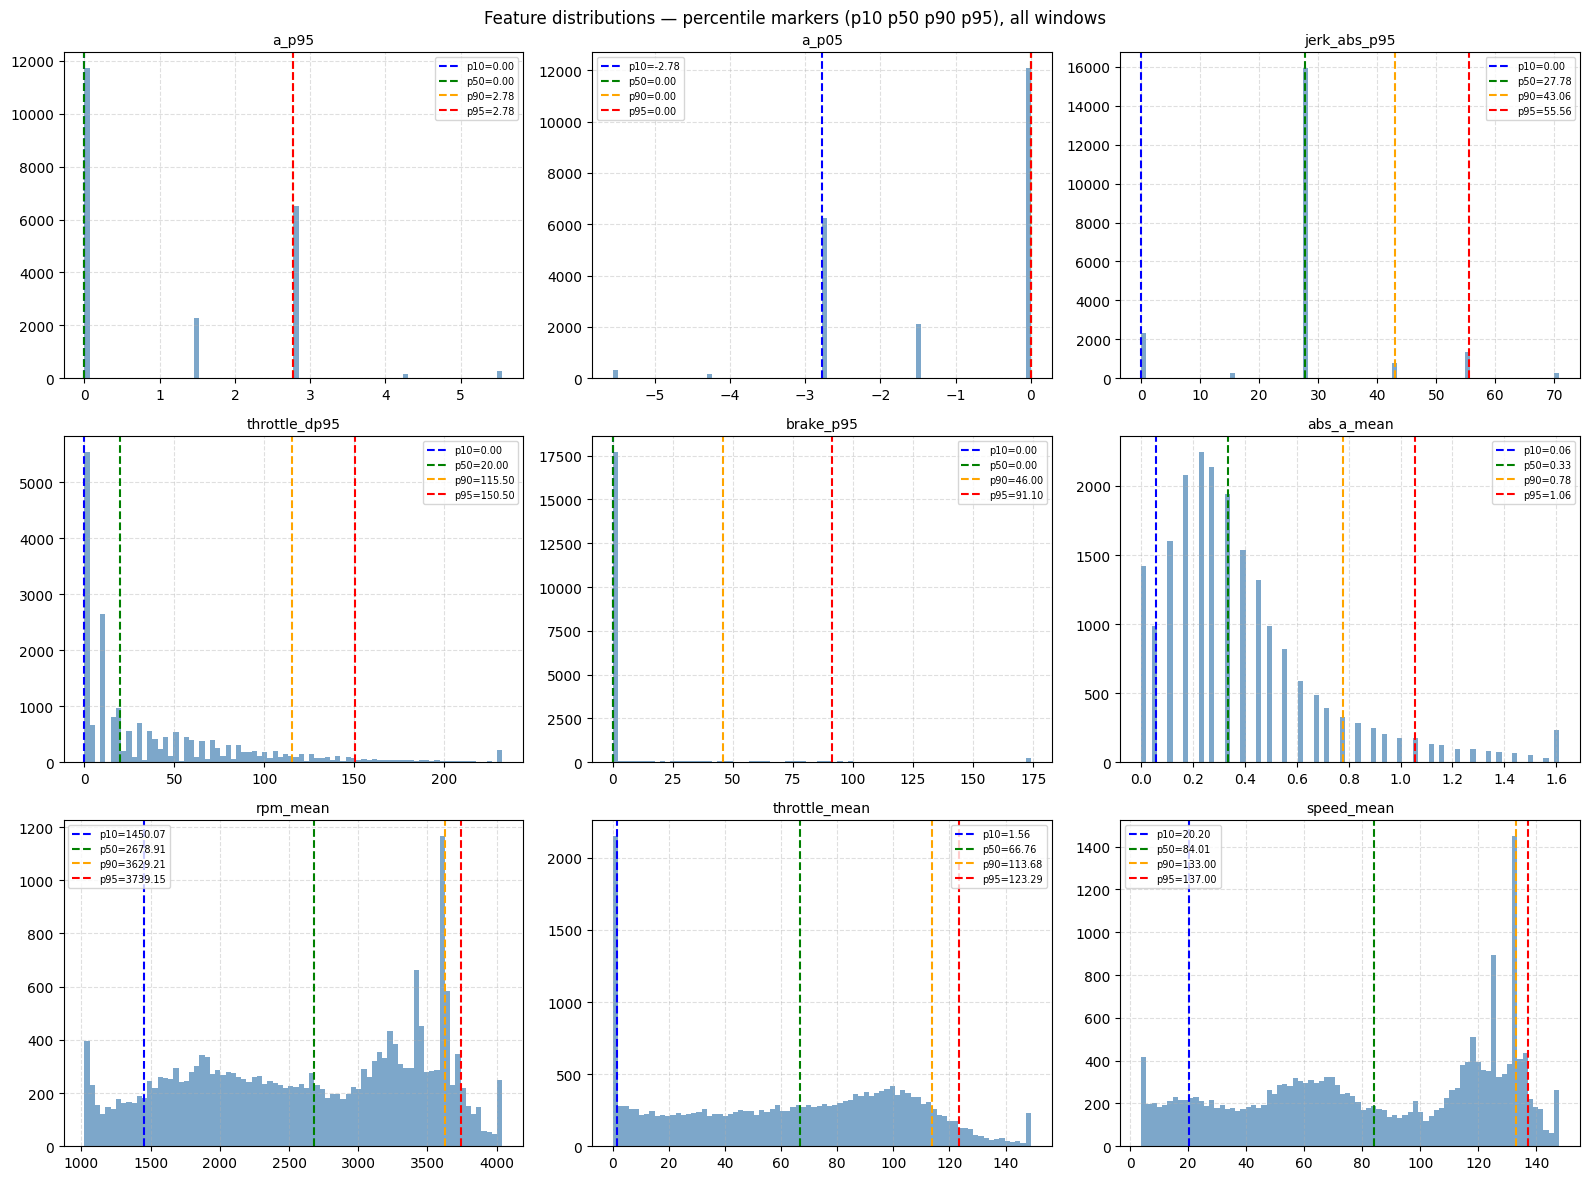

In [17]:
import matplotlib.pyplot as plt
import numpy as np

AGGR_FEATURES = ["a_p95", "a_p05", "jerk_abs_p95", "throttle_dp95", "brake_p95"]
ECO_FEATURES  = ["abs_a_mean", "rpm_mean", "throttle_dp95", "throttle_mean", "speed_mean"]

percs = [1, 5, 10, 25, 50, 75, 90, 95, 99]

print("=== Aggressive feature percentiles (all windows) ===")
aggr_stats = pd.DataFrame(
    {feat: np.percentile(feat_df[feat], percs) for feat in AGGR_FEATURES},
    index=[f"p{p}" for p in percs]
)
print(aggr_stats.to_string())

print("\n=== Eco feature percentiles (all windows) ===")
eco_stats = pd.DataFrame(
    {feat: np.percentile(feat_df[feat], percs) for feat in ECO_FEATURES},
    index=[f"p{p}" for p in percs]
)
print(eco_stats.to_string())

# Histograms with percentile markers (p10, p50, p90, p95)
ALL_VIZ = list(dict.fromkeys(AGGR_FEATURES + ECO_FEATURES))
ncols = 3
nrows = (len(ALL_VIZ) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

KEY_PERCS   = [10,    50,      90,       95   ]
PERC_COLORS = ["blue","green","orange","red"]

for ax, feat in zip(axes, ALL_VIZ):
    vals = feat_df[feat].values
    clip_lo = np.percentile(vals, 1)
    clip_hi = np.percentile(vals, 99)
    vals_c = np.clip(vals, clip_lo, clip_hi)
    ax.hist(vals_c, bins=80, color="steelblue", alpha=0.7, edgecolor="none")
    for p, lbl, col in zip(np.percentile(vals, KEY_PERCS),
                            [f"p{q}" for q in KEY_PERCS], PERC_COLORS):
        ax.axvline(p, color=col, linewidth=1.5, linestyle="--", label=f"{lbl}={p:.2f}")
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(True, linestyle="--", alpha=0.4)

for ax in axes[len(ALL_VIZ):]:
    ax.set_visible(False)

plt.suptitle("Feature distributions — percentile markers (p10 p50 p90 p95), all windows", fontsize=12)
plt.tight_layout()
plt.show()


## 7. Eksport rozwiązania do ESP32
Model zamieniany jest za pomocą `emlearn` na statycznie kompilowalny nagłówek C. Zapisujemy też meta dane o sposobie kwantyzacji wejścia na wartości od -30000 do 30000 w celu odtworzenia skalowania na mikrokontrolerze bez operacji zmiennoprzecinkowych. Zrzucamy to bezpośrednio do folderu `prepared_data/`.

**Schemat punktacji na ESP32** (sugestia):
- okno `eco` → `+2` punkty
- okno `normal` → `0` punktów
- okno `aggressive` → `-3` punkty

In [18]:
feat_df.to_csv(os.path.join(OUT_DIR, "windows_features_labeled.csv"), index=False)

fi = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)
fi.to_csv(os.path.join(OUT_DIR, "feature_importance_extratrees.csv"), index=False)

cmodel = emlearn.convert(
    model,
    method="inline",
    dtype="int16_t",
    leaf_bits=6
)
cmodel.save(
    file=os.path.join(OUT_DIR, "eco_model.h"),
    name="eco_model"
)

q_meta = {
    "feature_order": feature_cols,
    "scale": quantizer.scale_.tolist(),
    "min": quantizer.min_.tolist(),
    "class_order": CLASS_ORDER
}
with open(os.path.join(OUT_DIR, "feature_quantizer.json"), "w", encoding="utf-8") as f:
    json.dump(q_meta, f, indent=2)

print("Zakonczone. Model i dane zapisane w `prepared_data`.")

Zakonczone. Model i dane zapisane w `prepared_data`.


## 8. Wizualizacja nadanych etykiet
Wizualizacja pozwala nałożenie wygenerowanych pseudoetykiet (`normal`, `eco`, `aggressive`) na przebiegi surowych sygnałów z magistrali CAN (prędkość, gaz, hamulec) w czasie dla wybranego pliku z przejazdem. Dzięki temu weryfikujemy czy reguły poprawnie łapią zamierzone momenty (np. nagłe przyspieszenia jako agresywne, płynną jazdę jako eco).

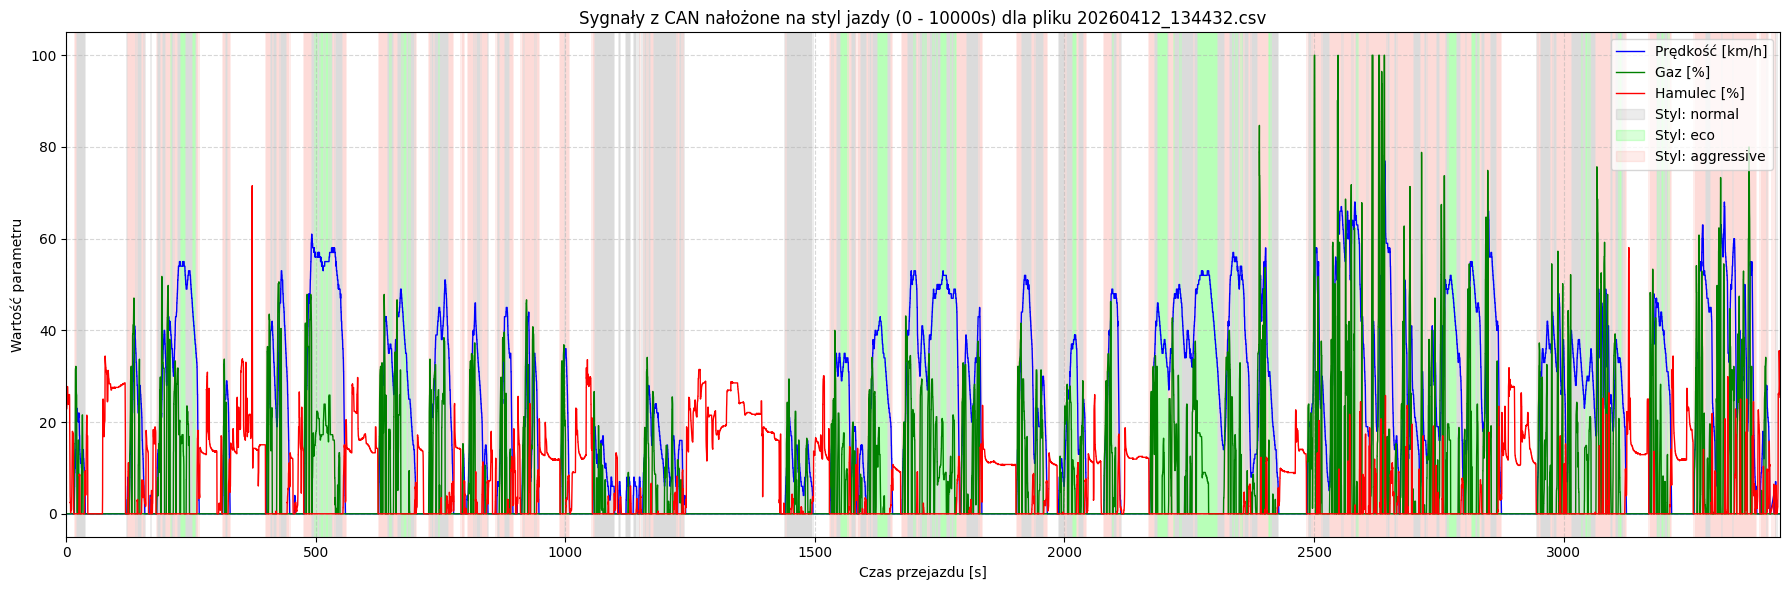

In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Pobieramy pierwszy z wczytanych przejazdów dla przykładu
sample_file = feat_df["source_file"].unique()[19]

# Wyciągamy dane
df_raw = raw_all[raw_all["source_file"] == sample_file].copy()
df_labels = feat_df[feat_df["source_file"] == sample_file].copy()

# Ustawiamy oś czasu w sekundach
t0 = df_raw["timestamp"].min()
df_raw["time_s"] = (df_raw["timestamp"] - t0) / 1000.0
df_labels["time_s"] = (df_labels["ts_end"] - t0) / 1000.0

# Ograniczenie wielkości okna do pierwszych 500 sekund (dla czytelności)
MAX_TIME = 10000.0
df_raw = df_raw[df_raw["time_s"] <= MAX_TIME]
df_labels = df_labels[df_labels["time_s"] <= MAX_TIME]

# Przeskalowanie sygnałów pedałów do 0-100% na potrzeby wizualizacji
# Przepustnica: 0-255 -> 0-100%, Hamulec: 0-1023 (0x3FF) -> 0-100%
df_raw["throttle_pct"] = df_raw["throttle"] / 2.55
df_raw["brake_pct"] = df_raw["brake"] / 10.23

fig, ax1 = plt.subplots(figsize=(18, 6))

# Rysowanie cienkich linii dla surowych sygnałów
ax1.plot(df_raw["time_s"], df_raw["speed"], color="blue", linewidth=1.0, label="Prędkość [km/h]")
ax1.plot(df_raw["time_s"], df_raw["throttle_pct"], color="green", linewidth=1.0, label="Gaz [%]")
ax1.plot(df_raw["time_s"], df_raw["brake_pct"], color="red", linewidth=1.0, label="Hamulec [%]")

# Mapa kolorów dla tła (etykiet). Używamy szarego dla normalnej jazdy, żeby nie zaburzał wykresu.
color_map = {"normal": "gray", "eco": "lime", "aggressive": "salmon"}

# Rysowanie tła (obszarów) dla przypisanych etykiet
# Okno u nas kończy się ts_end i trwa domyślnie WIN_SEC sekund.
for _, row in df_labels.iterrows():
    t_end = row["time_s"]
    t_start = max(0, t_end - WIN_SEC)
    label = row["label"]
    color = color_map.get(label, "white")
    
    # Rysujemy półprzezroczysty prostokąt, zmniejszone alpha dla większej przezroczystości
    ax1.axvspan(t_start, t_end, color=color, alpha=0.15, lw=0)

# Budowanie połączonej legendy (dla linii i dla teł)
lines, line_labels = ax1.get_legend_handles_labels()
bg_patches = [mpatches.Patch(color=color_map[k], alpha=0.15, label=f"Styl: {k}") for k in color_map]

ax1.legend(handles=lines + bg_patches, loc="upper right")
ax1.set_xlabel("Czas przejazdu [s]")
ax1.set_ylabel("Wartość parametru")
ax1.set_title(f"Sygnały z CAN nałożone na styl jazdy (0 - {int(MAX_TIME)}s) dla pliku {sample_file}")
ax1.grid(True, linestyle="--", alpha=0.5)

plt.xlim(0, df_raw["time_s"].max())
plt.tight_layout()
plt.show()